In [2]:
import pandas as pd

sequential_01_512_512_data_frame = pd.read_csv("./sequential/sequential_01/sequential_01_512_512.csv")
sequential_01_1024_1024_data_frame = pd.read_csv("./sequential/sequential_01/sequential_01_1024_1024.csv")

sequential_02_512_512_data_frame = pd.read_csv("./sequential/sequential_02/sequential_02_512_512.csv")
sequential_02_1024_1024_data_frame = pd.read_csv("./sequential/sequential_02/sequential_02_1024_1024.csv")

sequential_03_512_512_data_frame = pd.read_csv("./sequential/sequential_03/sequential_03_512_512.csv")
sequential_03_1024_1024_data_frame = pd.read_csv("./sequential/sequential_03/sequential_03_1024_1024.csv")

parallel_03_512_512_data_frame = pd.read_csv("./parallel/parallel_03/parallel_03_512_512.csv")
parallel_03_1024_1024_data_frame = pd.read_csv("./parallel/parallel_03/parallel_03_1024_1024.csv")

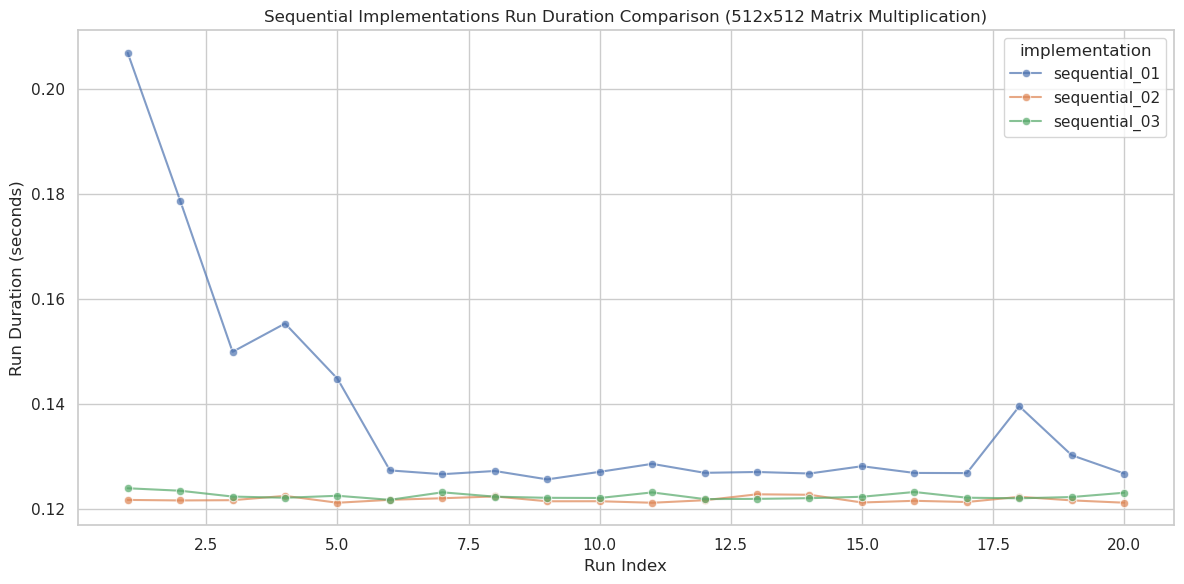

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.concat(
    [
        sequential_01_512_512_data_frame.assign(implementation="sequential_01"),
        sequential_02_512_512_data_frame.assign(implementation="sequential_02"),
        sequential_03_512_512_data_frame.assign(implementation="sequential_03"),
    ],
    ignore_index=True
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="run_duration_in_seconds",
    hue="implementation",
    marker="o",
    alpha=0.7
)

plt.title("Sequential Implementations Run Duration Comparison (512x512 Matrix Multiplication)")
plt.xlabel("Run Number")
plt.ylabel("Run Duration (seconds)")
plt.tight_layout()
plt.show()

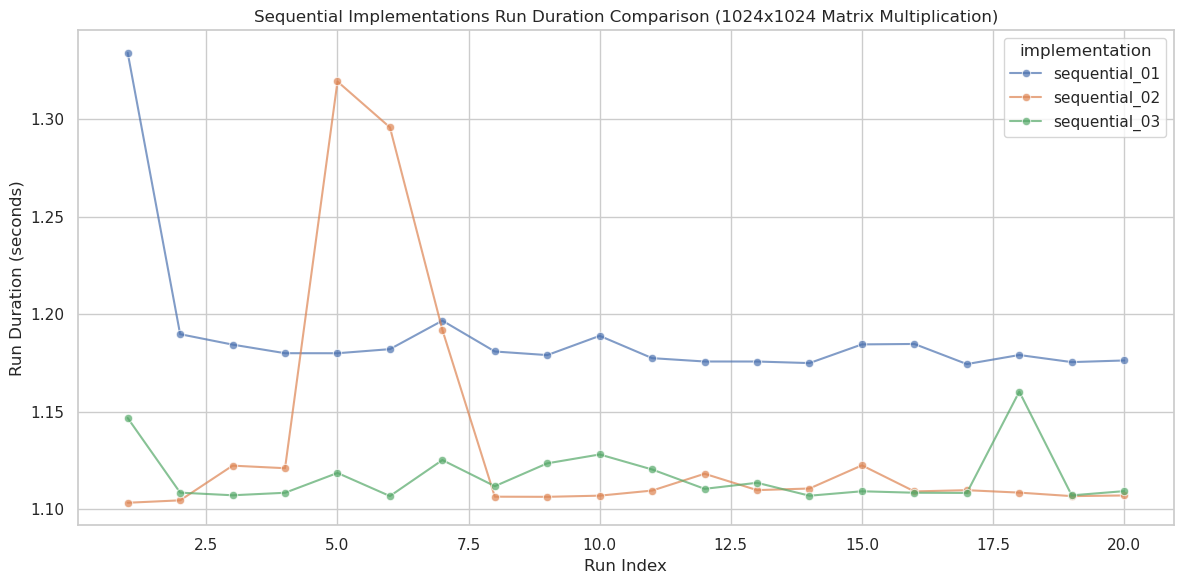

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.concat(
    [
        sequential_01_1024_1024_data_frame.assign(implementation="sequential_01"),
        sequential_02_1024_1024_data_frame.assign(implementation="sequential_02"),
        sequential_03_1024_1024_data_frame.assign(implementation="sequential_03"),
    ],
    ignore_index=True
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="run_duration_in_seconds",
    hue="implementation",
    marker="o",
    alpha=0.7
)

plt.title("Sequential Implementations Run Duration Comparison (1024x1024 Matrix Multiplication)")
plt.xlabel("Run Number")
plt.ylabel("Run Duration (seconds)")
plt.tight_layout()
plt.show()

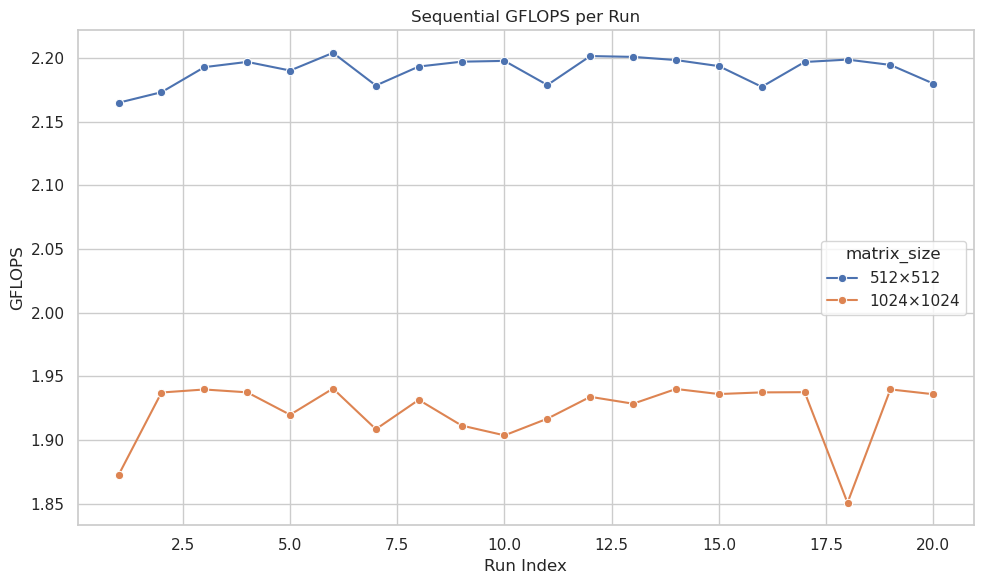

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_512 = sequential_03_512_512_data_frame.copy()
df_1024 = sequential_03_1024_1024_data_frame.copy()

df_512["matrix_size"] = "512×512"
df_1024["matrix_size"] = "1024×1024"

df = pd.concat([df_512, df_1024], ignore_index=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="gflops",
    hue="matrix_size",
    marker="o"
)

plt.title("Sequential GFLOPS per Run")
plt.xlabel("Run Index")
plt.ylabel("GFLOPS")
plt.tight_layout()
plt.show()

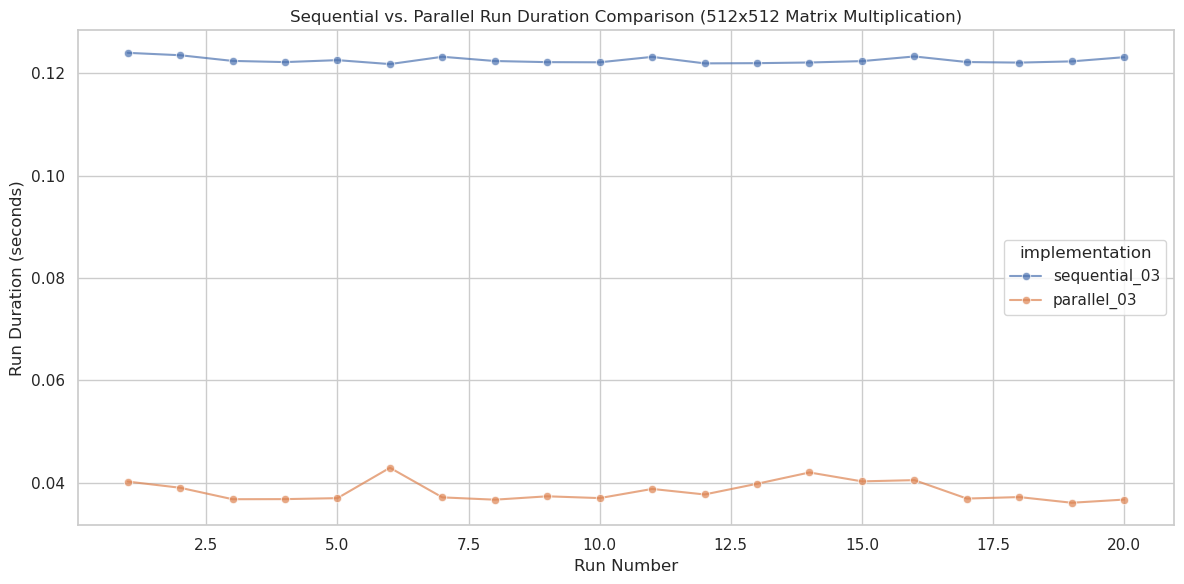

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.concat(
    [
        sequential_03_512_512_data_frame.assign(implementation="sequential_03"),
        parallel_03_512_512_data_frame.assign(implementation="parallel_03")
    ],
    ignore_index=True
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="run_duration_in_seconds",
    hue="implementation",
    marker="o",
    alpha=0.7
)

plt.title("Sequential vs. Parallel Run Duration Comparison (512x512 Matrix Multiplication)")
plt.xlabel("Run Number")
plt.ylabel("Run Duration (seconds)")
plt.tight_layout()
plt.show()

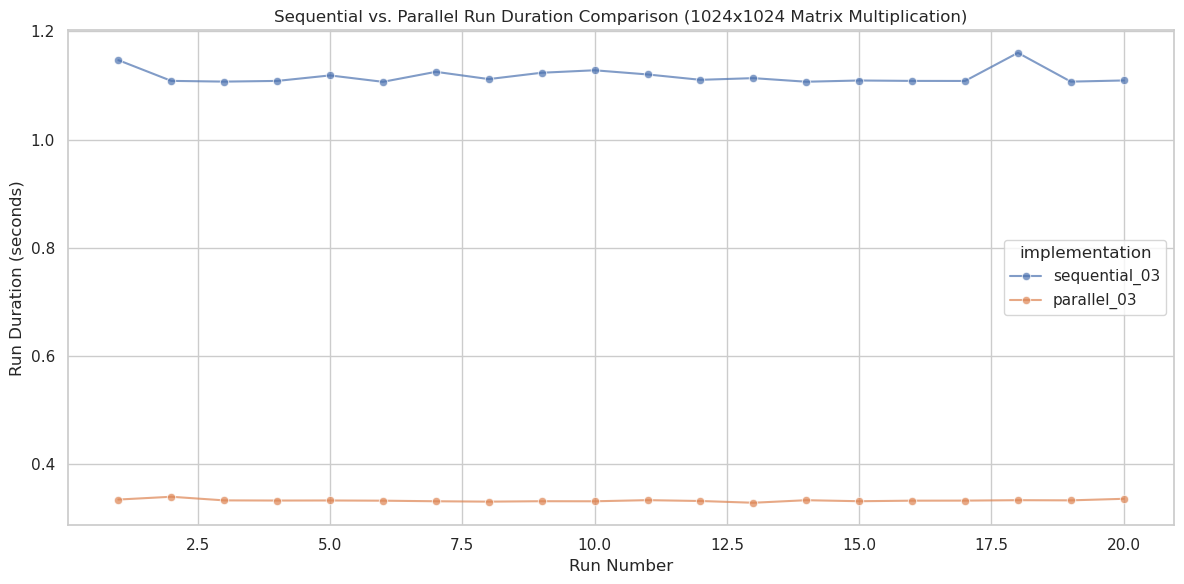

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.concat(
    [
        sequential_03_1024_1024_data_frame.assign(implementation="sequential_03"),
        parallel_03_1024_1024_data_frame.assign(implementation="parallel_03")
    ],
    ignore_index=True
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="run_duration_in_seconds",
    hue="implementation",
    marker="o",
    alpha=0.7
)

plt.title("Sequential vs. Parallel Run Duration Comparison (1024x1024 Matrix Multiplication)")
plt.xlabel("Run Number")
plt.ylabel("Run Duration (seconds)")
plt.tight_layout()
plt.show()

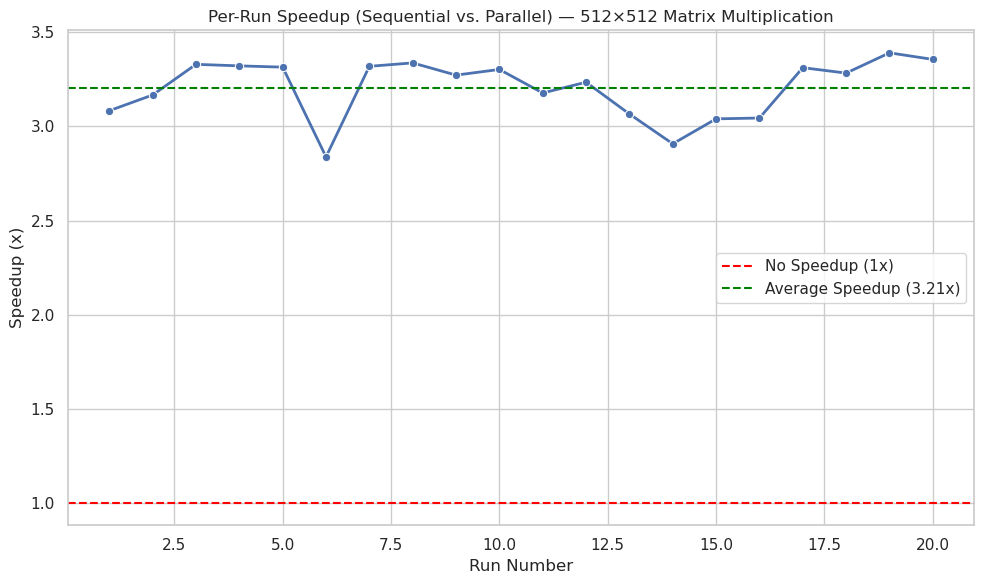

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

seq_df = sequential_03_512_512_data_frame[
    ["run_index", "run_duration_in_seconds"]
].rename(columns={
    "run_duration_in_seconds": "seq_time"
})

par_df = parallel_03_512_512_data_frame[
    ["run_index", "run_duration_in_seconds"]
].rename(columns={
    "run_duration_in_seconds": "par_time"
})

speedup_df = pd.merge(seq_df, par_df, on="run_index")

speedup_df["speedup"] = speedup_df["seq_time"] / speedup_df["par_time"]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=speedup_df,
    x="run_index",
    y="speedup",
    marker="o",
    linewidth=2
)

plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    label="No Speedup (1x)"
)

avg_speedup = speedup_df["speedup"].mean()
plt.axhline(
    y=avg_speedup,
    color="green",
    linestyle="--",
    label=f"Average Speedup ({avg_speedup:.2f}x)"
)

plt.title("Per-Run Speedup (Sequential vs. Parallel) — 512x512 Matrix Multiplication")
plt.xlabel("Run Number")
plt.ylabel("Speedup (x)")
plt.legend()
plt.tight_layout()
plt.show()

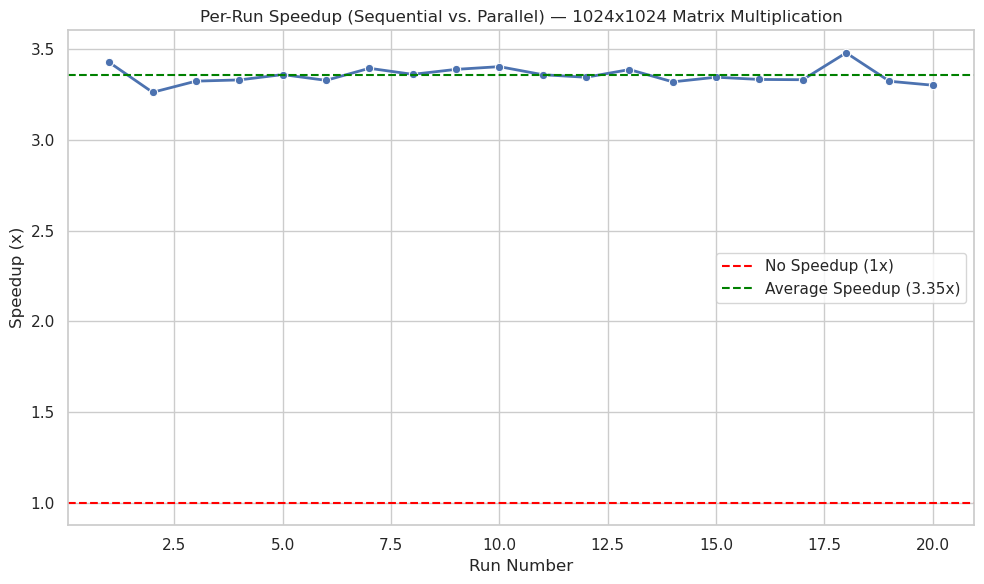

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

seq_df = sequential_03_1024_1024_data_frame[
    ["run_index", "run_duration_in_seconds"]
].rename(columns={
    "run_duration_in_seconds": "seq_time"
})

par_df = parallel_03_1024_1024_data_frame[
    ["run_index", "run_duration_in_seconds"]
].rename(columns={
    "run_duration_in_seconds": "par_time"
})

speedup_df = pd.merge(seq_df, par_df, on="run_index")

speedup_df["speedup"] = speedup_df["seq_time"] / speedup_df["par_time"]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=speedup_df,
    x="run_index",
    y="speedup",
    marker="o",
    linewidth=2
)

plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    label="No Speedup (1x)"
)

avg_speedup = speedup_df["speedup"].mean()
plt.axhline(
    y=avg_speedup,
    color="green",
    linestyle="--",
    label=f"Average Speedup ({avg_speedup:.2f}x)"
)

plt.title("Per-Run Speedup (Sequential vs. Parallel) — 1024x1024 Matrix Multiplication")
plt.xlabel("Run Number")
plt.ylabel("Speedup (x)")
plt.legend()
plt.tight_layout()
plt.show()

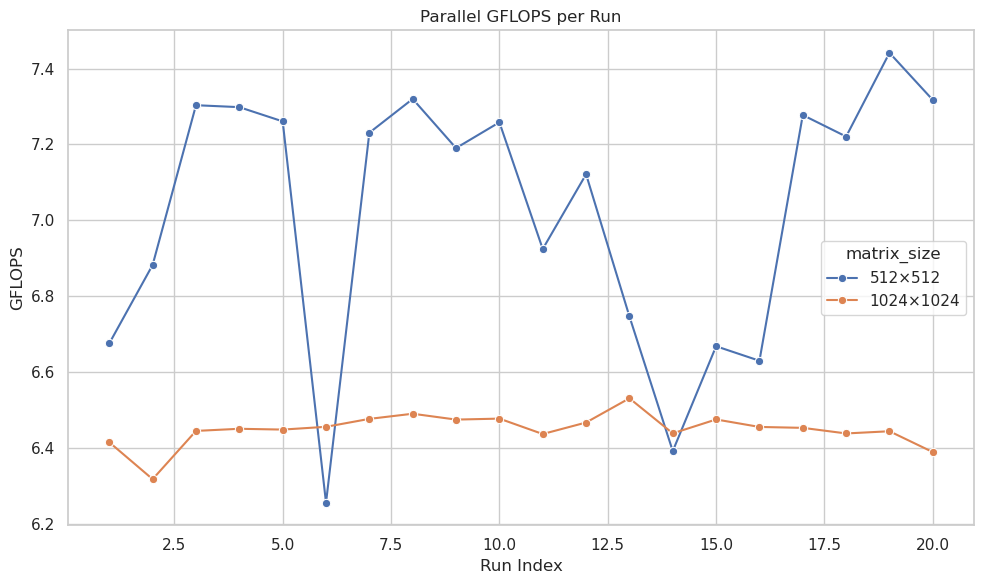

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_512 = parallel_03_512_512_data_frame.copy()
df_1024 = parallel_03_1024_1024_data_frame.copy()

df_512["matrix_size"] = "512×512"
df_1024["matrix_size"] = "1024×1024"

df = pd.concat([df_512, df_1024], ignore_index=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="run_index",
    y="gflops",
    hue="matrix_size",
    marker="o"
)

plt.title("Parallel GFLOPS per Run")
plt.xlabel("Run Index")
plt.ylabel("GFLOPS")
plt.tight_layout()
plt.show()